## Install Required Libraries

In [1]:
!pip install -q segmentation-models-pytorch==0.5.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 1.6 MB/s eta 0:00:00


In [2]:
import torch
import segmentation_models_pytorch as smp
import albumentations as A

print("Torch:", torch.__version__)
print("SMP:", smp.__version__)
print("Albumentations:", A.__version__)

Torch: 2.10.0+cu128
SMP: 0.5.0
Albumentations: 2.0.8


## Imports

In [3]:
import os
import cv2
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

import torchvision.transforms as T

import albumentations as A
from albumentations.pytorch import ToTensorV2

import segmentation_models_pytorch as smp

import warnings
warnings.filterwarnings("ignore")

## GPU Verification

In [4]:
print("CUDA Available:", torch.cuda.is_available())

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", DEVICE)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

CUDA Available: True
Device: cuda
GPU: Tesla T4


## Reproducibility

In [5]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

## Dataset Paths

In [6]:
DATASET_DIR = (
    "/kaggle/input/datasets/neeldaiict/xbd-tier3-preprocessed"
)

train_csv = os.path.join(
    DATASET_DIR,
    "train_masks.csv"
)

val_csv = os.path.join(
    DATASET_DIR,
    "val_masks.csv"
)

test_csv = os.path.join(
    DATASET_DIR,
    "test_masks.csv"
)

## Loading CSV Files

In [7]:
train_df = pd.read_csv(train_csv)

val_df = pd.read_csv(val_csv)

test_df = pd.read_csv(test_csv)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 4458
Validation: 955
Test: 956


## Fixing Mask Paths

In [8]:
MASK_ROOT = os.path.join(
    DATASET_DIR,
    "processed_masks"
)

def fix_mask_path(relative_path):

    relative_path = relative_path.replace(
        "processed_masks/",
        ""
    )

    return os.path.join(
        MASK_ROOT,
        relative_path
    )

train_df["mask_path"] = train_df["mask_path"].apply(fix_mask_path)
val_df["mask_path"] = val_df["mask_path"].apply(fix_mask_path)
test_df["mask_path"] = test_df["mask_path"].apply(fix_mask_path)

## Verify Dataset Paths

In [9]:
sample = train_df.iloc[0]

print(sample["post_image"])
print()

print(sample["mask_path"])
print()

print(
    "Mask Exists:",
    os.path.exists(
        sample["mask_path"]
    )
)

/kaggle/input/datasets/tunguz/xview2-challenge-dataset-tier-3-data/tier3/images/sunda-tsunami_00000085_post_disaster.png

/kaggle/input/datasets/neeldaiict/xbd-tier3-preprocessed/processed_masks/train/sunda-tsunami_00000085_post_disaster_mask.png

Mask Exists: True


## Damage Classes

In [10]:
CLASS_NAMES = {
    0: "Background",
    1: "No Damage",
    2: "Minor Damage",
    3: "Major Damage",
    4: "Destroyed"
}

NUM_CLASSES = 5

print(CLASS_NAMES)

{0: 'Background', 1: 'No Damage', 2: 'Minor Damage', 3: 'Major Damage', 4: 'Destroyed'}


## Image Augmentations

In [11]:
IMAGE_SIZE = 256

train_transform = A.Compose([

    A.HorizontalFlip(p=0.5),

    A.VerticalFlip(p=0.5),

    A.RandomRotate90(p=0.5),

    A.Normalize(),

    ToTensorV2()

])

val_transform = A.Compose([

    A.Normalize(),

    ToTensorV2()

])

## xBD Dataset Class

In [12]:
class XBDDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform=None
    ):

        self.df = dataframe.reset_index(drop=True)

        self.transform = transform

    def __len__(self):

        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        post_img = np.array(
            Image.open(
                row["post_image"]
            ).convert("RGB")
        )

        mask = np.array(
            Image.open(
                row["mask_path"]
            )
        )

        post_img = cv2.resize(
            post_img,
            (IMAGE_SIZE, IMAGE_SIZE)
        )

        mask = cv2.resize(
            mask,
            (IMAGE_SIZE, IMAGE_SIZE),
            interpolation=cv2.INTER_NEAREST
        )

        if self.transform:

            transformed = self.transform(
                image=post_img,
                mask=mask
            )

            post_img = transformed["image"]

            mask = transformed["mask"]

        return (
            post_img.float(),
            mask.long()
        )

## Create Dataset Objects

In [13]:
train_dataset = XBDDataset(
    train_df,
    transform=train_transform
)

val_dataset = XBDDataset(
    val_df,
    transform=val_transform
)

test_dataset = XBDDataset(
    test_df,
    transform=val_transform
)

## Create DataLoaders

In [14]:
BATCH_SIZE = 8

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(
    "Train Batches:",
    len(train_loader)
)

print(
    "Validation Batches:",
    len(val_loader)
)

print(
    "Test Batches:",
    len(test_loader)
)

Train Batches: 558
Validation Batches: 120
Test Batches: 120


## Verifying DataLoader Output

In [15]:
images, masks = next(
    iter(train_loader)
)

print(
    "Images Shape:",
    images.shape
)

print(
    "Masks Shape:",
    masks.shape
)

Images Shape: torch.Size([8, 3, 256, 256])
Masks Shape: torch.Size([8, 256, 256])


## Visual Verification

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8781574..2.6399999].


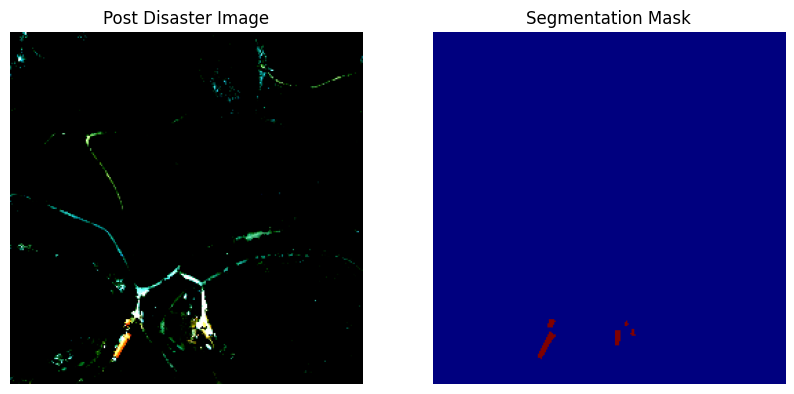

In [16]:
sample_img = images[0]

sample_mask = masks[0]

post_img = (
    sample_img
    .permute(1, 2, 0)
    .cpu()
    .numpy()
)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(post_img)
plt.title("Post Disaster Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(
    sample_mask.cpu().numpy(),
    cmap="jet"
)
plt.title("Segmentation Mask")
plt.axis("off")

plt.show()

## Computing Class Weights

In [17]:
pixel_counts = {
    0: 410469786,
    1: 5564167,
    2: 540478,
    3: 347612,
    4: 476741
}

total_pixels = sum(pixel_counts.values())

class_weights = []

for cls in range(NUM_CLASSES):

    freq = pixel_counts[cls] / total_pixels

    weight = 1.0 / (freq + 1e-8)

    class_weights.append(weight)

class_weights = np.array(class_weights)

class_weights = (
    class_weights /
    class_weights.sum()
) * NUM_CLASSES

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(DEVICE)

print("Class Weights:")
print(class_weights)

Class Weights:
tensor([1.7385e-03, 1.2825e-01, 1.3203e+00, 2.0529e+00, 1.4968e+00],
       device='cuda:0')


## Multi-class Dice Loss

In [18]:
class DiceLoss(nn.Module):

    def __init__(self, smooth=1e-6):
        super().__init__()

        self.smooth = smooth

    def forward(self, logits, targets):

        probs = torch.softmax(
            logits,
            dim=1
        )

        targets_one_hot = torch.nn.functional.one_hot(
            targets,
            NUM_CLASSES
        )

        targets_one_hot = (
            targets_one_hot
            .permute(0,3,1,2)
            .float()
        )

        intersection = (
            probs *
            targets_one_hot
        ).sum((0,2,3))

        union = (
            probs +
            targets_one_hot
        ).sum((0,2,3))

        dice = (
            2.0 * intersection +
            self.smooth
        ) / (
            union +
            self.smooth
        )

        return 1.0 - dice.mean()

## Combined Loss

In [19]:
ce_loss = nn.CrossEntropyLoss(
    weight=class_weights
)

dice_loss = DiceLoss()

def combined_loss(
    logits,
    targets
):

    ce = ce_loss(
        logits,
        targets
    )

    dice = dice_loss(
        logits,
        targets
    )

    return (
        0.5 * ce +
        0.5 * dice
    )

## SMP U-Net

In [20]:
model = smp.Unet(

    encoder_name="resnet34",

    encoder_weights="imagenet",

    in_channels=3,

    classes=NUM_CLASSES

)

model = model.to(DEVICE)

print("Model created successfully")

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Model created successfully


## Model Parameters

In [21]:
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(
    f"Total Parameters: {total_params:,}"
)

print(
    f"Trainable Parameters: {trainable_params:,}"
)

Total Parameters: 24,436,949
Trainable Parameters: 24,436,949


## Forward Pass Verification

In [22]:
images, masks = next(
    iter(train_loader)
)

images = images.to(DEVICE)

with torch.no_grad():

    outputs = model(images)

print(
    "Input Shape:",
    images.shape
)

print(
    "Output Shape:",
    outputs.shape
)

Input Shape: torch.Size([8, 3, 256, 256])
Output Shape: torch.Size([8, 5, 256, 256])


## Mean IoU Metric

In [23]:
def calculate_iou(
    preds,
    targets,
    num_classes=NUM_CLASSES
):

    preds = torch.argmax(
        preds,
        dim=1
    )

    ious = []

    for cls in range(num_classes):

        pred_inds = (
            preds == cls
        )

        target_inds = (
            targets == cls
        )

        intersection = (
            pred_inds &
            target_inds
        ).sum().item()

        union = (
            pred_inds |
            target_inds
        ).sum().item()

        if union == 0:
            continue

        ious.append(
            intersection / union
        )

    if len(ious) == 0:
        return 0.0

    return np.mean(ious)

## Dice Metric

In [24]:
def calculate_dice(
    preds,
    targets,
    num_classes=NUM_CLASSES
):

    preds = torch.argmax(
        preds,
        dim=1
    )

    scores = []

    for cls in range(num_classes):

        pred_inds = (
            preds == cls
        )

        target_inds = (
            targets == cls
        )

        intersection = (
            pred_inds &
            target_inds
        ).sum().item()

        total = (
            pred_inds.sum().item() +
            target_inds.sum().item()
        )

        if total == 0:
            continue

        dice = (
            2 * intersection
        ) / total

        scores.append(dice)

    if len(scores) == 0:
        return 0.0

    return np.mean(scores)

## Optimizer

In [25]:
optimizer = optim.AdamW(

    model.parameters(),

    lr=1e-4,

    weight_decay=1e-4
)

## Learning Rate Scheduler

In [26]:
scheduler = optim.lr_scheduler.ReduceLROnPlateau(

    optimizer,

    mode="min",

    factor=0.5,

    patience=2
)

## Automatic Mixed Precision (AMP)

In [27]:
scaler = torch.amp.GradScaler(
    "cuda"
)

## Final verification before training

In [28]:
images, masks = next(
    iter(train_loader)
)

images = images.to(DEVICE)

with torch.no_grad():

    outputs = model(images)

loss = combined_loss(
    outputs,
    masks.to(DEVICE)
)

iou = calculate_iou(
    outputs.cpu(),
    masks
)

dice = calculate_dice(
    outputs.cpu(),
    masks
)

print(
    "Loss:",
    loss.item()
)

print(
    "IoU:",
    iou
)

print(
    "Dice:",
    dice
)

Loss: 1.4524115324020386
IoU: 0.0030827448801396666
Dice: 0.006125873092112623


## Training Function

In [29]:
def train_one_epoch(
    model,
    loader,
    optimizer,
    scaler
):

    model.train()

    running_loss = 0.0
    running_iou = 0.0
    running_dice = 0.0

    progress_bar = tqdm(
        loader,
        desc="Training",
        leave=False
    )

    for images, masks in progress_bar:

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        masks = masks.to(
            DEVICE,
            non_blocking=True
        )

        optimizer.zero_grad()

        with torch.amp.autocast(
            device_type="cuda"
        ):

            outputs = model(images)

            loss = combined_loss(
                outputs,
                masks
            )

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        running_loss += loss.item()

        running_iou += calculate_iou(
            outputs.detach().cpu(),
            masks.detach().cpu()
        )

        running_dice += calculate_dice(
            outputs.detach().cpu(),
            masks.detach().cpu()
        )

    epoch_loss = running_loss / len(loader)

    epoch_iou = running_iou / len(loader)

    epoch_dice = running_dice / len(loader)

    return (
        epoch_loss,
        epoch_iou,
        epoch_dice
    )

## Validation Function

In [30]:
@torch.no_grad()

def validate_one_epoch(
    model,
    loader
):

    model.eval()

    running_loss = 0.0
    running_iou = 0.0
    running_dice = 0.0

    progress_bar = tqdm(
        loader,
        desc="Validation",
        leave=False
    )

    for images, masks in progress_bar:

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        masks = masks.to(
            DEVICE,
            non_blocking=True
        )

        outputs = model(images)

        loss = combined_loss(
            outputs,
            masks
        )

        running_loss += loss.item()

        running_iou += calculate_iou(
            outputs.cpu(),
            masks.cpu()
        )

        running_dice += calculate_dice(
            outputs.cpu(),
            masks.cpu()
        )

    epoch_loss = running_loss / len(loader)

    epoch_iou = running_iou / len(loader)

    epoch_dice = running_dice / len(loader)

    return (
        epoch_loss,
        epoch_iou,
        epoch_dice
    )

## Early Stopping

In [31]:
class EarlyStopping:

    def __init__(
        self,
        patience=5,
        min_delta=0.0001
    ):

        self.patience = patience
        self.min_delta = min_delta

        self.best_loss = np.inf

        self.counter = 0

        self.stop = False

    def __call__(
        self,
        val_loss
    ):

        if val_loss < (
            self.best_loss -
            self.min_delta
        ):

            self.best_loss = val_loss

            self.counter = 0

        else:

            self.counter += 1

            if self.counter >= self.patience:

                self.stop = True

## Model Path

In [32]:
MODEL_PATH = "best_unet_resnet34_post_only.pth"

print(MODEL_PATH)

best_unet_resnet34_post_only.pth


## Training History

In [33]:
history = {

    "train_loss": [],
    "val_loss": [],

    "train_iou": [],
    "val_iou": [],

    "train_dice": [],
    "val_dice": []
}

## Training Configuration

In [34]:
NUM_EPOCHS = 80

early_stopping = EarlyStopping(
    patience=8
)

best_val_loss = np.inf

## Model Training

In [35]:
for epoch in range(NUM_EPOCHS):

    print(
        f"\nEpoch "
        f"{epoch+1}/{NUM_EPOCHS}"
    )

    train_loss, train_iou, train_dice = (
        train_one_epoch(
            model,
            train_loader,
            optimizer,
            scaler
        )
    )

    val_loss, val_iou, val_dice = (
        validate_one_epoch(
            model,
            val_loader
        )
    )

    scheduler.step(
        val_loss
    )

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    history["train_iou"].append(train_iou)
    history["val_iou"].append(val_iou)

    history["train_dice"].append(train_dice)
    history["val_dice"].append(val_dice)

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f}")

    print(f"Train IoU: {train_iou:.4f}")
    print(f"Val IoU: {val_iou:.4f}")

    print(f"Train Dice: {train_dice:.4f}")
    print(f"Val Dice: {val_dice:.4f}")

    current_lr = optimizer.param_groups[0]["lr"]

    print(
        f"Learning Rate: {current_lr:.6f}"
    )

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            model.state_dict(),
            MODEL_PATH
        )

        print("Best model saved.")

    early_stopping(val_loss)

    if early_stopping.stop:

        print(
            "\nEarly stopping triggered."
        )

        break


Epoch 1/80


Train Loss: 1.1030
Val Loss: 0.9073
Train IoU: 0.1352
Val IoU: 0.2035
Train Dice: 0.1674
Val Dice: 0.2372
Learning Rate: 0.000100
Best model saved.

Epoch 2/80


Train Loss: 0.8584
Val Loss: 0.7597
Train IoU: 0.2148
Val IoU: 0.2144
Train Dice: 0.2505
Val Dice: 0.2528
Learning Rate: 0.000100
Best model saved.

Epoch 3/80


Train Loss: 0.7891
Val Loss: 0.7050
Train IoU: 0.2263
Val IoU: 0.2262
Train Dice: 0.2653
Val Dice: 0.2666
Learning Rate: 0.000100
Best model saved.

Epoch 4/80


Train Loss: 0.7483
Val Loss: 0.7094
Train IoU: 0.2361
Val IoU: 0.2451
Train Dice: 0.2782
Val Dice: 0.2890
Learning Rate: 0.000100

Epoch 5/80


...

Train Loss: 0.5574
Val Loss: 0.6061
Train IoU: 0.2712
Val IoU: 0.2683
Train Dice: 0.3269
Val Dice: 0.3202
Learning Rate: 0.000013

Epoch 24/80


Train Loss: 0.5572
Val Loss: 0.6039
Train IoU: 0.2726
Val IoU: 0.2782
Train Dice: 0.3284
Val Dice: 0.3328
Learning Rate: 0.000013

Epoch 25/80


Train Loss: 0.5516
Val Loss: 0.6059
Train IoU: 0.2722
Val IoU: 0.2747
Train Dice: 0.3276
Val Dice: 0.3290
Learning Rate: 0.000006

Epoch 26/80


Train Loss: 0.5450
Val Loss: 0.6052
Train IoU: 0.2749
Val IoU: 0.2697
Train Dice: 0.3315
Val Dice: 0.3227
Learning Rate: 0.000006

Epoch 27/80


Train Loss: 0.5404
Val Loss: 0.6061
Train IoU: 0.2772
Val IoU: 0.2802
Train Dice: 0.3346
Val Dice: 0.3351
Learning Rate: 0.000006

Early stopping triggered.


## Loading the Best model

In [36]:
MODEL_PATH = "best_unet_resnet34_post_only.pth"

model.load_state_dict(
    torch.load(
        MODEL_PATH,
        map_location=DEVICE
    )
)

model.eval()

print("Best model loaded successfully.")

Best model loaded successfully.


## Per-class IoU

In [37]:
def per_class_iou(
    preds,
    targets,
    num_classes=NUM_CLASSES
):

    preds = torch.argmax(
        preds,
        dim=1
    )

    iou_scores = {}

    for cls in range(num_classes):

        pred_mask = (
            preds == cls
        )

        target_mask = (
            targets == cls
        )

        intersection = (
            pred_mask &
            target_mask
        ).sum().item()

        union = (
            pred_mask |
            target_mask
        ).sum().item()

        if union == 0:

            iou_scores[cls] = np.nan

        else:

            iou_scores[cls] = (
                intersection / union
            )

    return iou_scores

## Per-class Dice

In [38]:
def per_class_dice(
    preds,
    targets,
    num_classes=NUM_CLASSES
):

    preds = torch.argmax(
        preds,
        dim=1
    )

    dice_scores = {}

    for cls in range(num_classes):

        pred_mask = (
            preds == cls
        )

        target_mask = (
            targets == cls
        )

        intersection = (
            pred_mask &
            target_mask
        ).sum().item()

        total = (
            pred_mask.sum().item() +
            target_mask.sum().item()
        )

        if total == 0:

            dice_scores[cls] = np.nan

        else:

            dice_scores[cls] = (
                2 * intersection
            ) / total

    return dice_scores

## Class mapping

In [39]:
CLASS_NAMES = {

    0: "Background",
    1: "No Damage",
    2: "Minor Damage",
    3: "Major Damage",
    4: "Destroyed"
}

## Test Evaluation

In [40]:
test_loss = 0.0

test_iou = 0.0
test_dice = 0.0

all_class_iou = {
    i: []
    for i in range(NUM_CLASSES)
}

all_class_dice = {
    i: []
    for i in range(NUM_CLASSES)
}

model.eval()

with torch.no_grad():

    for images, masks in tqdm(test_loader):

        images = images.to(DEVICE)

        masks = masks.to(DEVICE)

        outputs = model(images)

        loss = combined_loss(
            outputs,
            masks
        )

        test_loss += loss.item()

        test_iou += calculate_iou(
            outputs.cpu(),
            masks.cpu()
        )

        test_dice += calculate_dice(
            outputs.cpu(),
            masks.cpu()
        )

        batch_iou = per_class_iou(
            outputs.cpu(),
            masks.cpu()
        )

        batch_dice = per_class_dice(
            outputs.cpu(),
            masks.cpu()
        )

        for cls in range(NUM_CLASSES):

            if not np.isnan(batch_iou[cls]):
                all_class_iou[cls].append(
                    batch_iou[cls]
                )

            if not np.isnan(batch_dice[cls]):
                all_class_dice[cls].append(
                    batch_dice[cls]
                )

test_loss /= len(test_loader)
test_iou /= len(test_loader)
test_dice /= len(test_loader)

print("\nTest Results")
print("-"*40)

print(f"Loss : {test_loss:.4f}")
print(f"Mean IoU : {test_iou:.4f}")
print(f"Mean Dice : {test_dice:.4f}")

100%|██████████| 120/120 [01:02<00:00,  1.92it/s]


Test Results
----------------------------------------
Loss : 0.6357
Mean IoU : 0.2674
Mean Dice : 0.3220


## Per-class Metrics

In [41]:
results = []

for cls in range(NUM_CLASSES):

    mean_iou = np.mean(
        all_class_iou[cls]
    )

    mean_dice = np.mean(
        all_class_dice[cls]
    )

    results.append({

        "Class ID": cls,

        "Class Name": CLASS_NAMES[cls],

        "IoU": round(mean_iou,4),

        "Dice": round(mean_dice,4)

    })

metrics_df = pd.DataFrame(results)

metrics_df

,Class ID,Class Name,IoU,Dice
0,0,Background,0.9385,0.9677
1,1,No Damage,0.2704,0.4161
2,2,Minor Damage,0.0514,0.0929
3,3,Major Damage,0.0428,0.0776
4,4,Destroyed,0.0255,0.0473


## IoU Visualization

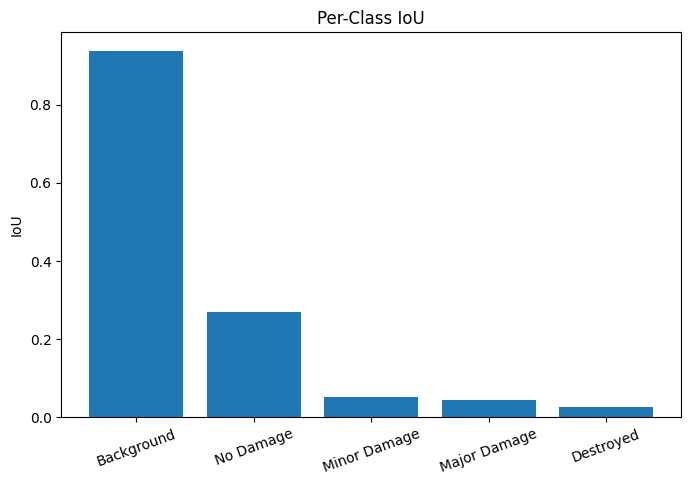

In [42]:
plt.figure(figsize=(8,5))

plt.bar(
    metrics_df["Class Name"],
    metrics_df["IoU"]
)

plt.title("Per-Class IoU")

plt.ylabel("IoU")

plt.xticks(rotation=20)

plt.show()

## Dice Visualization

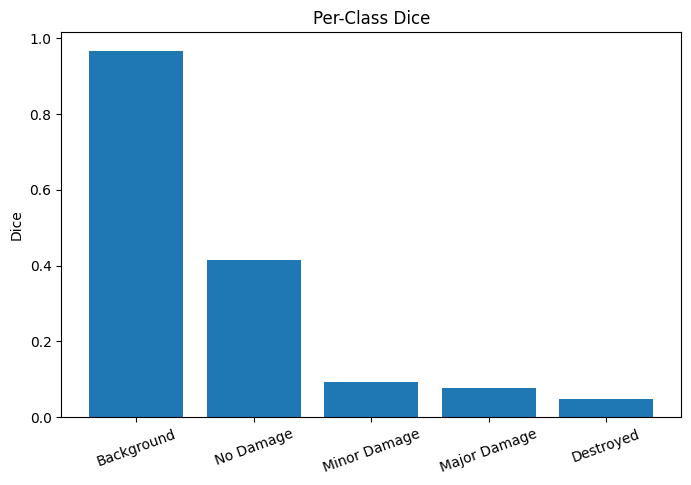

In [43]:
plt.figure(figsize=(8,5))

plt.bar(
    metrics_df["Class Name"],
    metrics_df["Dice"]
)

plt.title("Per-Class Dice")

plt.ylabel("Dice")

plt.xticks(rotation=20)

plt.show()

## Training Curves

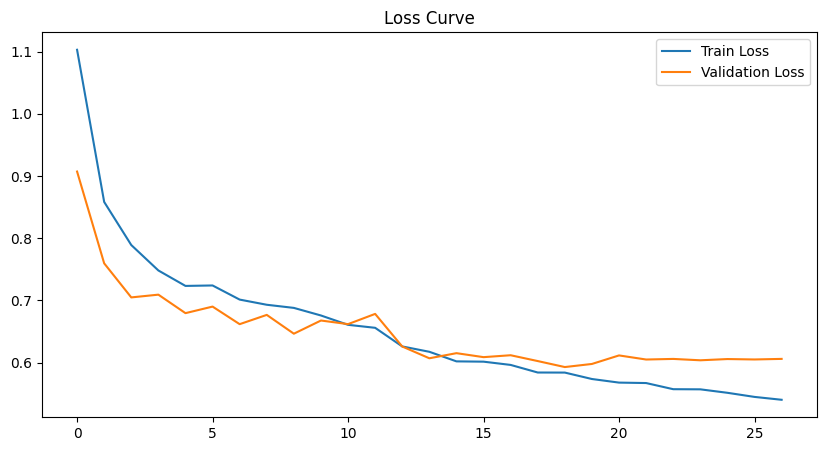

In [44]:
plt.figure(figsize=(10,5))

plt.plot(
    history["train_loss"],
    label="Train Loss"
)

plt.plot(
    history["val_loss"],
    label="Validation Loss"
)

plt.legend()

plt.title("Loss Curve")

plt.show()

## IoU Curve

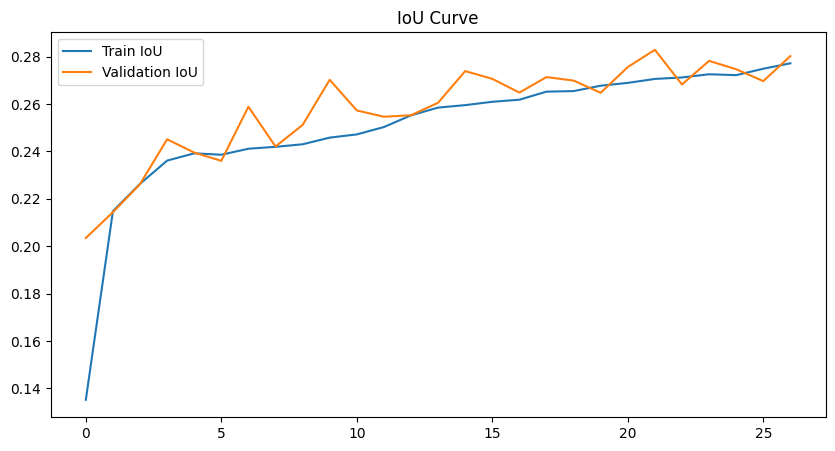

In [45]:
plt.figure(figsize=(10,5))

plt.plot(
    history["train_iou"],
    label="Train IoU"
)

plt.plot(
    history["val_iou"],
    label="Validation IoU"
)

plt.legend()

plt.title("IoU Curve")

plt.show()

## Dice Curve

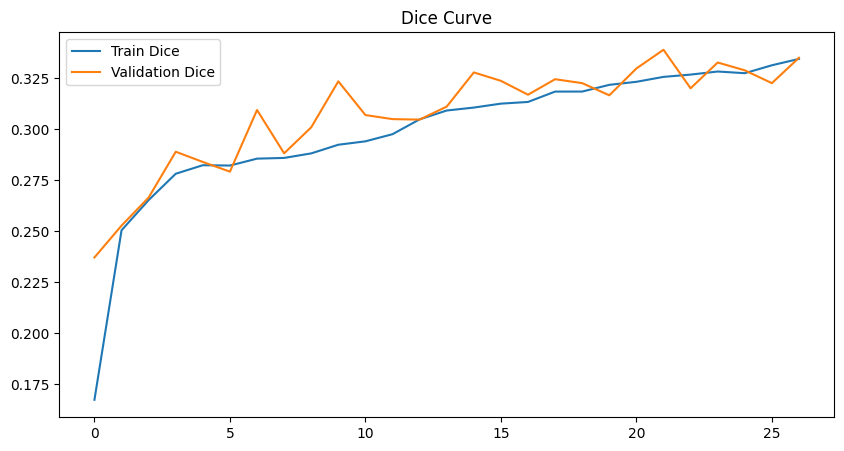

In [46]:
plt.figure(figsize=(10,5))

plt.plot(
    history["train_dice"],
    label="Train Dice"
)

plt.plot(
    history["val_dice"],
    label="Validation Dice"
)

plt.legend()

plt.title("Dice Curve")

plt.show()

## Prediction Visualization

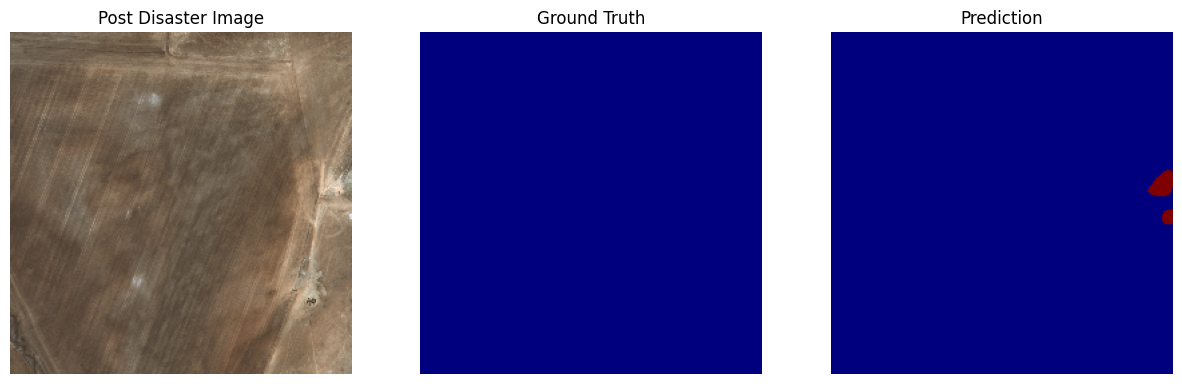

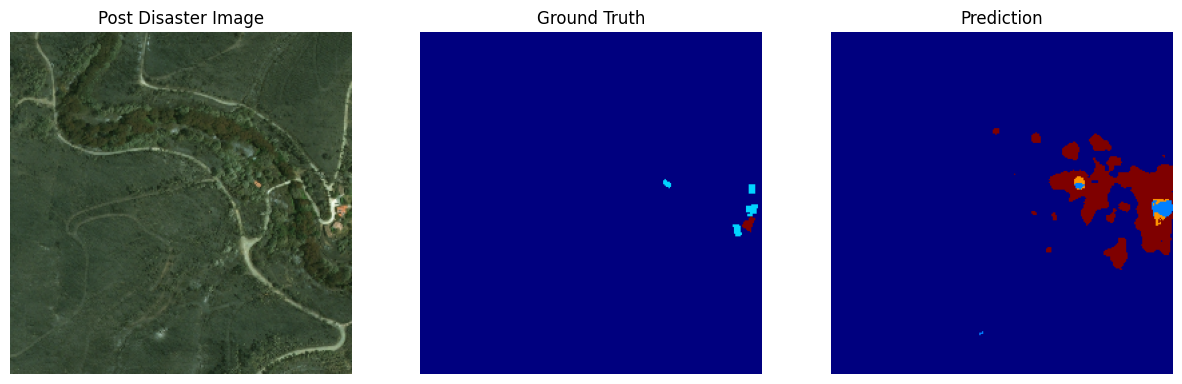

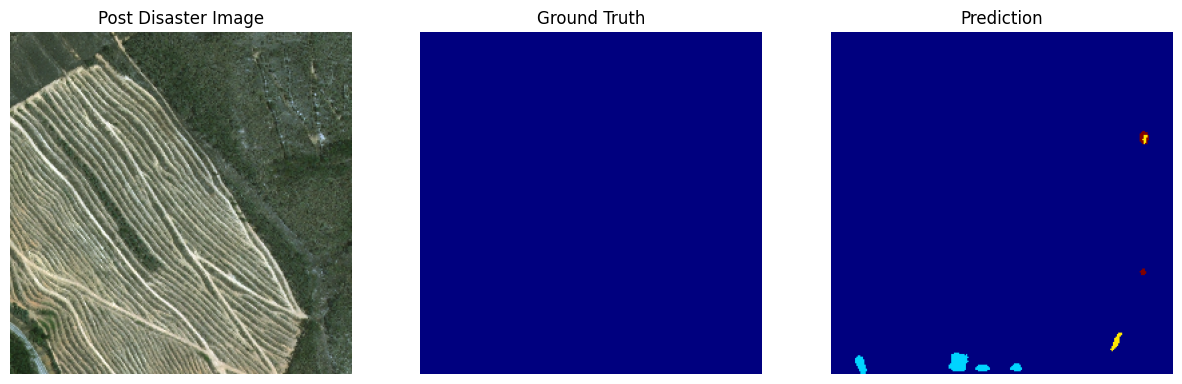

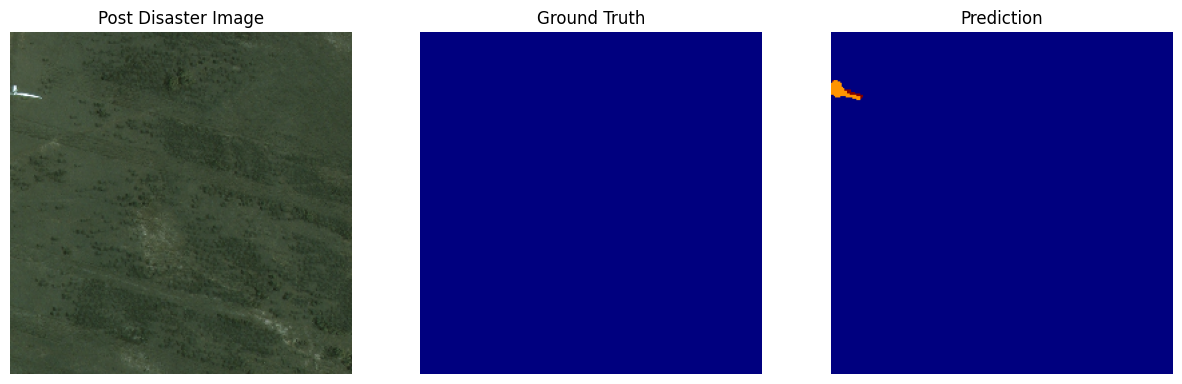

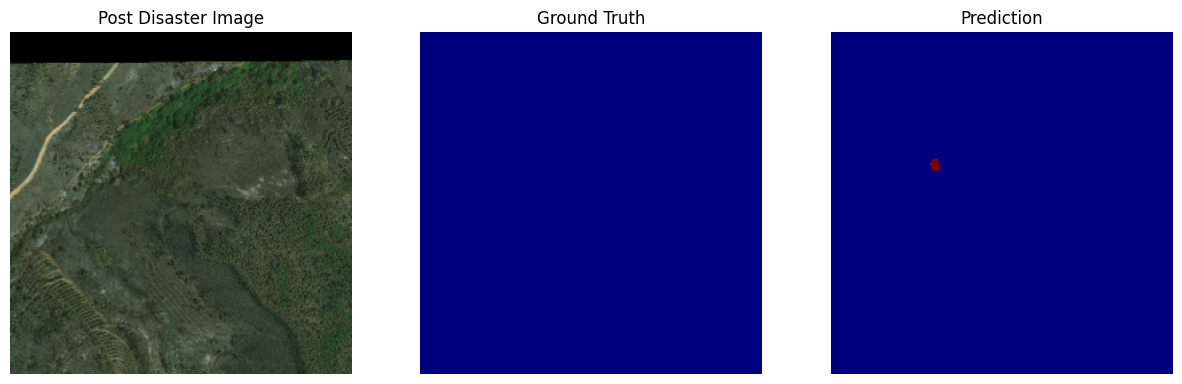

In [47]:
num_samples = 5

model.eval()

for _ in range(num_samples):

    idx = np.random.randint(
        0,
        len(test_dataset)
    )

    image, mask = test_dataset[idx]

    with torch.no_grad():

        pred = model(
            image.unsqueeze(0).to(DEVICE)
        )

    pred = torch.argmax(
        pred,
        dim=1
    )

    pred = (
        pred.squeeze()
        .cpu()
        .numpy()
    )

    post_img = (
        image
        .permute(1,2,0)
        .numpy()
    )

    # Undo normalization
    post_img = (
        post_img *
        np.array([0.229,0.224,0.225])
        +
        np.array([0.485,0.456,0.406])
    )

    post_img = np.clip(post_img,0,1)

    gt_mask = mask.numpy()

    plt.figure(figsize=(15,5))

    plt.subplot(1,3,1)
    plt.imshow(post_img)
    plt.title("Post Disaster Image")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(
        gt_mask,
        cmap="jet"
    )
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(
        pred,
        cmap="jet"
    )
    plt.title("Prediction")
    plt.axis("off")

    plt.show()

## Saving metrics

In [48]:
metrics_df.to_csv(
    "test_metrics.csv",
    index=False
)

print("Saved: test_metrics.csv")

Saved: test_metrics.csv
